In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:
content = pd.read_csv ("dataset/train_val.csv")
test_content = pd.read_csv ("dataset/test.csv")

print ("Shape: ")
print (content.shape)

print (content.head())

Shape: 
(15482, 8)
   Unnamed: 0           id                   channel  \
0           0  --2s6hjGrm4  UC-1rx8j9Ggp8mp4uD0ZdEIA   
1           1  --DnfroyKQ8  UC-1rx8j9Ggp8mp4uD0ZdEIA   
2           2  --aiU7VQKEw  UC-1rx8j9Ggp8mp4uD0ZdEIA   
3           6  -0SrlZAvSVM  UCW6NyJ6oFLPTnx7iGRZXDDg   
4          10  -13Y2Pe7kFs  UC-1rx8j9Ggp8mp4uD0ZdEIA   

                                               title  \
0  CGI & VFX Breakdowns: "Warzone" - by Ramesh Th...   
1  A Sci-Fi Short Film: "Exit" - by Ng King Kwan ...   
2  CGI 3D Animated Short: "Lost Love" - by Akash ...   
3  Jo Goes Hunting - Careful | Animated music vid...   
4  CGI VFX Breakdown: "Logan (Wolverine): Digital...   

                        date  \
0  2020-12-15 05:00:01+00:00   
1  2020-07-01 16:00:00+00:00   
2  2019-02-18 20:30:00+00:00   
3  2020-03-10 14:30:01+00:00   
4  2017-09-20 20:13:52+00:00   

                                         description   views  year  
0  Check out this revealing VFX Breakdown "Wa

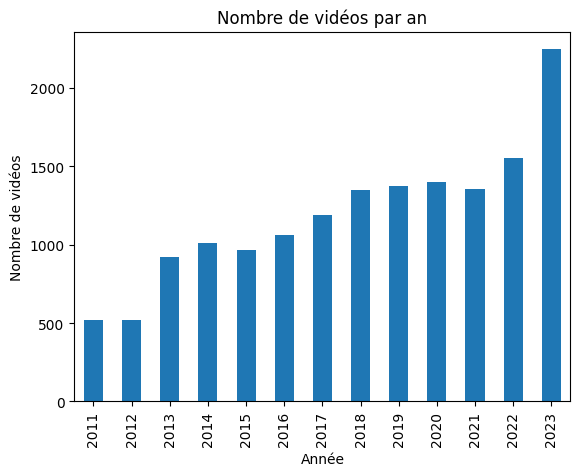

In [11]:
content['year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Année')
plt.ylabel('Nombre de vidéos')
plt.title('Nombre de vidéos par an')
plt.show()


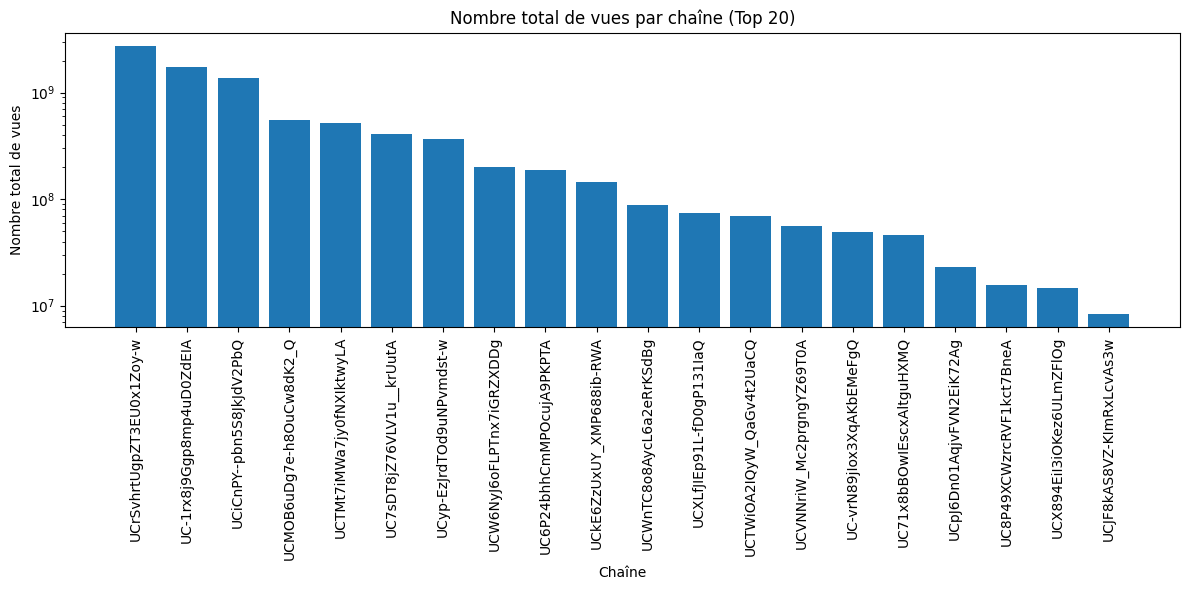

In [6]:
# Calculer le nombre total de vues par chaîne
vues_par_chaine_df = content.groupby('channel')['views'].sum().sort_values(ascending=False)

# Sélectionner les 20 premières chaînes
top_n = 20
top_channels = vues_par_chaine_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_channels.index, top_channels.values)
plt.yscale('log')
plt.xlabel('Chaîne')
plt.ylabel('Nombre total de vues')
plt.title('Nombre total de vues par chaîne (Top 20)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [15]:
# Charger les chaînes uniques du fichier test.csv
test_content = pd.read_csv("dataset/test.csv")
test_channels = set(test_content['channel'].unique())

# Chaînes uniques dans train_val.csv (déjà chargé dans 'content')
train_val_channels = set(content['channel'].unique())

# Chaînes présentes dans test.csv mais pas dans train_val.csv
unique_test_channels = test_channels - train_val_channels

print(f"Nombre de chaînes dans test.csv qui ne sont pas dans train_val.csv : {len(unique_test_channels)}")

Nombre de chaînes dans test.csv qui ne sont pas dans train_val.csv : 0


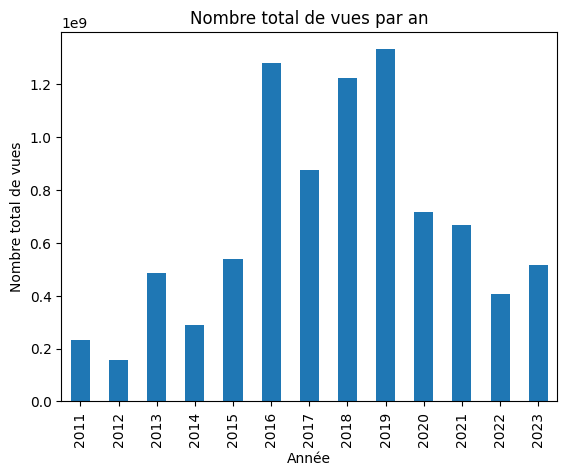

In [12]:

content.groupby('year')['views'].sum().sort_index().plot(kind='bar')
plt.xlabel('Année')
plt.ylabel('Nombre total de vues')
plt.title('Nombre total de vues par an')
plt.show()


In [ ]:
"""On regarde le nombre total de vues par chaine"""

import math

vues_par_chaines = {}

for index in range (len (content["channel"])) :
    nomChaine = content["channel"][index]
    vuesVideo = content["views"][index]
    if nomChaine not in vues_par_chaines :
        vues_par_chaines[nomChaine] = 0
    vues_par_chaines[nomChaine] += vuesVideo
        
maxVues = vues_par_chaines [max(vues_par_chaines, key=vues_par_chaines.get)]

chaines_cat = []

tktVues = maxVues
while (tktVues > 1):
    tktVues /= 10
    chaines_cat.append (0)


for nomChaine, nbVues in vues_par_chaines.items ():
    facteur10 = 0
    tktVues = nbVues
    while (tktVues > 1) :
        facteur10 += 1
        tktVues /= 10
    chaines_cat [facteur10 - 1] += 1
    print (nomChaine, nbVues, facteur10 - 1)

print (chaines_cat)

plt.bar (chaines_cat, nb_vues_cat)
plt.show ()



UC-1rx8j9Ggp8mp4uD0ZdEIA 1733933273 9
UCW6NyJ6oFLPTnx7iGRZXDDg 201193175 8
UCXLfJIEp91L-fD0gP131IaQ 74200244 7
UCrSvhrtUgpZT3EU0x1Zoy-w 2726157311 9
UCpUhcwq3oB7HKvrNeQmxJsg 143768 5
UC71x8bBOwIEscxAltguHXMQ 46317526 7
UCiCnPY--pbn5S8JkJdV2PbQ 1374780673 9
UC6P24bhhCmMPOcujA9PKPTA 189120740 8
UC7sDT8jZ76VLV1u__krUutA 412612361 8
UCMOB6uDg7e-h8OuCw8dK2_Q 553195959 8
UCJF8kAS8VZ-KImRxLcvAs3w 8373311 6
UCX894EiI3iOKez6ULmZFlOg 14747939 7
UCUrJu1fEq7kH9CBXaPH0PGw 1396694 6
UC8P49XCWzrcRVF1kct7BneA 15597766 7
UCN5mdjo8Odux4PvR297-K4Q 982338 5
UC6qhhbnMeoOPFBf-cjUgn3g 192593 5
UCVNNriW_Mc2prgngYZ69T0A 56462046 7
UCFfovcqnybrMbIrNjyND-nA 1710635 6
UC9DAY2JD9zy9zKA5OtwpNtw 731769 5
UCDp2VWtNgiaTjkhfCvdZmjA 1838753 6
UCIAegrInVcw19QXmblowt2g 5850637 6
UCN9-Y2E0_fLxtcWAgr89CsQ 1131249 6
UCcRbWavyHkNsXdfot0yo8zw 5305417 6
UCHUnLXalwe66kBndfmH5cXA 60950 4
UCZtZ5HkDba6_zM_wpaQn60w 751368 5
UC9pJs4nFKM9xuW_enR4hHig 1268610 6
UCrUPTKJg_Oe-Bc4aC5CzrEQ 748538 5
UCk6Znl7ryh2dKCX5opiu7ng 242880 5
UCTMt7i

NameError: name 'cat' is not defined

In [5]:
# Associer un numéro unique à chaque channel présent dans la table content
channels = content['channel'].unique()
channel_ids_df = pd.DataFrame({'channel': channels, 'channel_id': range(1, len(channels) + 1)})

# Sauvegarder dans un fichier CSV
channel_ids_df.to_csv('channel_ids.csv', index=False)

In [ ]:
test_content = 

In [18]:
# Ajouter la colonne 'channel_id' dans train_val.csv
content_with_id = content.merge(channel_ids_df, on='channel', how='left')
content_with_id.head()

,Unnamed: 0,id,channel,title,date,description,views,year,channel_id
0,0,--2s6hjGrm4,UC-1rx8j9Ggp8mp4uD0ZdEIA,"CGI & VFX Breakdowns: ""Warzone"" - by Ramesh Th...",2020-12-15 05:00:01+00:00,"Check out this revealing VFX Breakdown ""Warzon...",12299,2020,1
1,1,--DnfroyKQ8,UC-1rx8j9Ggp8mp4uD0ZdEIA,"A Sci-Fi Short Film: ""Exit"" - by Ng King Kwan ...",2020-07-01 16:00:00+00:00,"TheCGBros Presents ""Exit"" by Ng King Kwan - Th...",7494,2020,1
2,2,--aiU7VQKEw,UC-1rx8j9Ggp8mp4uD0ZdEIA,"CGI 3D Animated Short: ""Lost Love"" - by Akash ...",2019-02-18 20:30:00+00:00,"TheCGBros Presents ""Lost Love"" by Akash Manack...",11831,2019,1
3,6,-0SrlZAvSVM,UCW6NyJ6oFLPTnx7iGRZXDDg,Jo Goes Hunting - Careful | Animated music vid...,2020-03-10 14:30:01+00:00,"On the borderless map of a magical planet, lit...",2248,2020,2
4,10,-13Y2Pe7kFs,UC-1rx8j9Ggp8mp4uD0ZdEIA,"CGI VFX Breakdown: ""Logan (Wolverine): Digital...",2017-09-20 20:13:52+00:00,Check out this outstanding behind-the-scenes l...,113806,2017,1


In [19]:
content_with_id.to_csv("dataset/train_val.csv", index=False)